In [3]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import seaborn as sns

sns.set_theme()
sns.set_style("ticks")
sns.set_context("talk")
sns.color_palette("colorblind")

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

# By-hand exact calculations for grand canonical Hamiltonian expectation value with Gutzwiller wavefunction

In [ ]:
from scipy.optimize import minimize_scalar

U = 10.0
t = 1.0
mu = 4.2
n_max = 8  # match your VMC truncation

def f_vec(kappa, n_max):
    n = np.arange(n_max + 1, dtype=float)
    # unnormalized amplitudes
    f = np.exp(-0.5 * kappa * n**2) / np.sqrt([math.factorial(int(m)) for m in n])
    # normalize in |f|^2
    f = f / np.sqrt(np.sum(f**2))
    return f

def energy_2site_gutz(kappa):
    f = f_vec(kappa, n_max)
    n = np.arange(n_max + 1, dtype=float)

    # single-site moments
    nbar = np.sum(n * f**2)
    nnm1 = np.sum(n * (n - 1) * f**2)

    # <b> on one site
    bbar = 0.0
    for m in range(n_max):
        bbar += math.sqrt(m + 1) * f[m] * f[m + 1]

    # 2-site energy with one bond
    H_U  = U * nnm1                  # 2 sites: 2*(U/2*<n(n-1)>) = U*<n(n-1)>
    H_mu = -2 * mu * nbar
    H_K  = -2 * t * (bbar**2)

    return H_K + H_U + H_mu

res = minimize_scalar(energy_2site_gutz, bounds=(1e-8, 10), method="bounded")
print(f"Optimal kappa = {res.x:.12f}")
print(f"Minimum H(kappa) = {energy_2site_gutz(res.x):.12f}")

Optimal kappa = 0.318180148464
Minimum H(kappa) = -3.894310942704


In [4]:
def load_vmc_vr(filepath):
    data = np.loadtxt(filepath, comments="#", ndmin=2)

    r = data[:, 0].astype(int)
    vr = data[:, 1]

    return r, vr

In [5]:
def build_vr_filepath(base_dir, U):
    return f"{base_dir}/VMC_vr_vs_r_U{U:.1f}.dat"


def plot_vr_panels(base_dir, U_values, ncols=3, figsize=(12, 7), savepath=None):
    nfiles = len(U_values)
    nrows = int(np.ceil(nfiles / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=figsize,
        sharex=True,
        sharey=False
    )
    axes = np.atleast_1d(axes).ravel()

    for i, U in enumerate(U_values):
        ax = axes[i]
        filepath = build_vr_filepath(base_dir, U)

        r, vr = load_vmc_vr(filepath)

        ax.plot(
            r, vr,
            'o--',
            color='black',
            linewidth=2,
            markersize=4,
            label='Our VMC'
        )

        ax.set_title(rf"$U/t = {U:.1f}$", fontsize=18)
        ax.tick_params(axis='both', labelsize=13, width=1.5, length=6)

        if i % ncols == 0:
            ax.set_ylabel(r"$v_r$", fontsize=20)

        if i >= (nrows - 1) * ncols:
            ax.set_xlabel(r"$r$", fontsize=20)

        ax.legend(frameon=False, fontsize=11, loc='best')

    for j in range(nfiles, len(axes)):
        axes[j].axis("off")

    fig.suptitle(r"$L=60,\,N=60$")
    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()

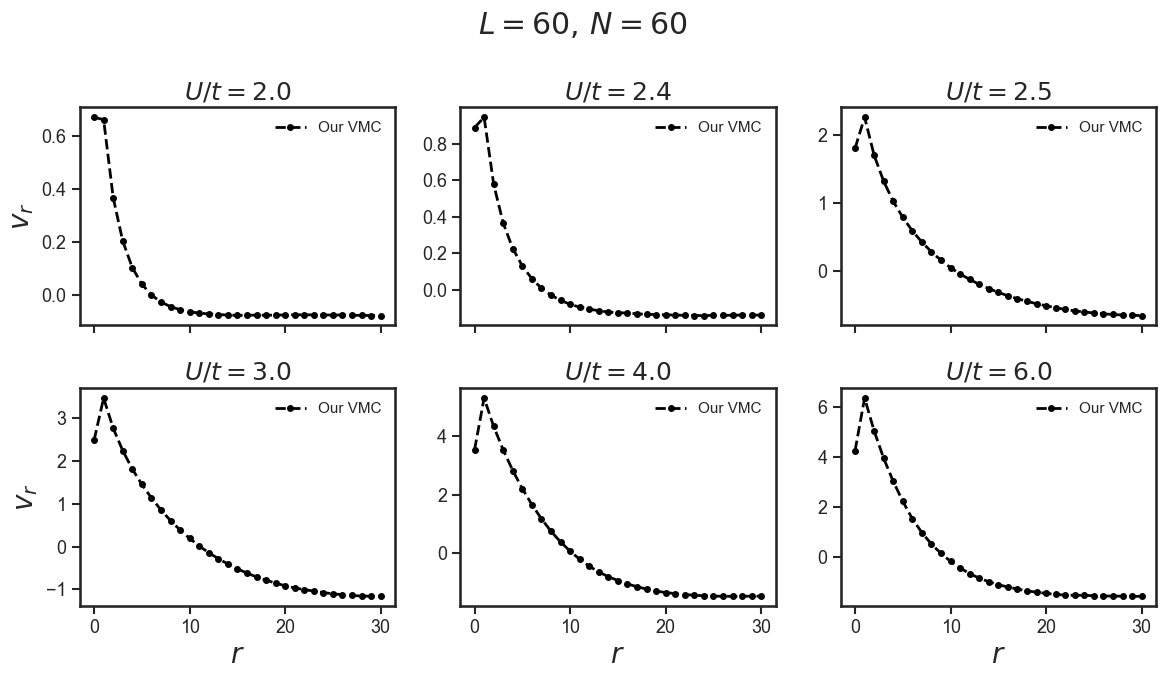

In [6]:
base_dir = "../data/C/1D/L60_N60/jastrow_realspace"

U_values = np.array([2.0, 2.4, 2.5, 3.0, 4.0, 6.0])

plot_vr_panels(
    base_dir=base_dir,
    U_values=U_values,
    ncols=3,
    figsize=(12, 7),
    savepath=None
)

In [7]:

def realspace_to_momentum_jastrow_exclude_q0(vr, L, subtract_tail=False, tail_size=5):
    """
    Transform reduced real-space Jastrow coefficients vr[R]
    into the momentum-space kernel V_q corresponding to

        log Psi = -(1/(2L)) * sum_q V_q n_q n_{-q}

    excluding q = 0 from the returned arrays.

    Parameters
    ----------
    vr : array-like
        Real-space Jastrow coefficients with vr[0] = R=0, ..., vr[Rmax] = Rmax.
        Must have length Rmax + 1 where Rmax = L//2.
    L : int
        System size.
    subtract_tail : bool, optional
        If True, subtract the mean of the last `tail_size` entries of vr before transforming.
    tail_size : int, optional
        Number of tail points used for mean subtraction.

    Returns
    -------
    q_vals : np.ndarray
        Nonzero momentum values q = 2*pi*m/L for m = 1, ..., Rmax.
    Vq : np.ndarray
        Momentum-space Jastrow kernel evaluated at those q values.
    """
    vr = np.asarray(vr, dtype=float)
    Rmax = L // 2

    if len(vr) != Rmax + 1:
        raise ValueError(f"Expected len(vr) = {Rmax + 1}, got {len(vr)}")

    vr_work = vr.copy()

    if subtract_tail:
        n_tail = min(tail_size, len(vr_work))
        tail_mean = np.mean(vr_work[-n_tail:])
        vr_work -= tail_mean

    # Exclude q=0 by starting m at 1
    m_vals = np.arange(1, Rmax + 1)
    q_vals = 2.0 * np.pi * m_vals / L
    Vq = np.zeros_like(q_vals, dtype=float)

    if L % 2 == 0:
        for iq, q in enumerate(q_vals):
            s = 2.0 * vr_work[0]  # R = 0

            for R in range(1, Rmax):
                s += 4.0 * vr_work[R] * np.cos(q * R)

            s += 2.0 * vr_work[Rmax] * np.cos(q * Rmax)  # R = L/2 special term
            Vq[iq] = s
    else:
        for iq, q in enumerate(q_vals):
            s = 2.0 * vr_work[0]  # R = 0

            for R in range(1, Rmax + 1):
                s += 4.0 * vr_work[R] * np.cos(q * R)

            Vq[iq] = s

    return q_vals, Vq

In [8]:
r, vr = load_vmc_vr("../data/C/1D/L60_N60/jastrow_realspace/VMC_vr_vs_r_U8.0.dat")

L = 60

q_vals, Vq = realspace_to_momentum_jastrow_exclude_q0(vr, L, subtract_tail=False)

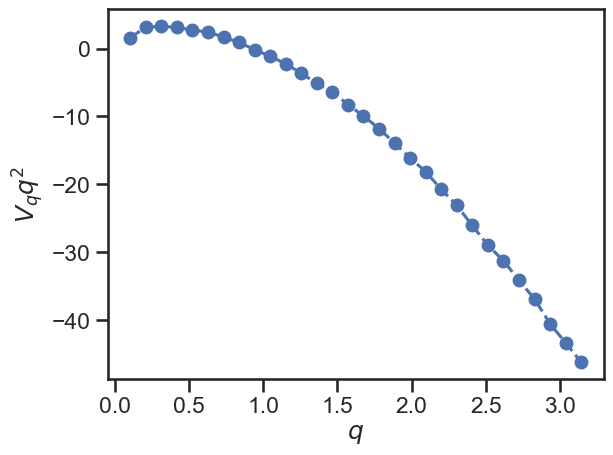

In [9]:
import matplotlib.pyplot as plt

plt.plot(q_vals, Vq * q_vals**2, 'o--')
plt.xlabel(r"$q$")
plt.ylabel(r"$V_q q^2$")
plt.show()

# Testing how different $v_q$ values are for L = 64, N = 63, 64, 65

## Momentum Space Jastrow Potentials

In [10]:
def load_vmc_vq(filepath):
    data = np.loadtxt(filepath, comments="#", ndmin=2)

    q = data[:, 0]
    vq = data[:, 1]
    vq_q2 = data[:, 2]

    return q, vq, vq_q2

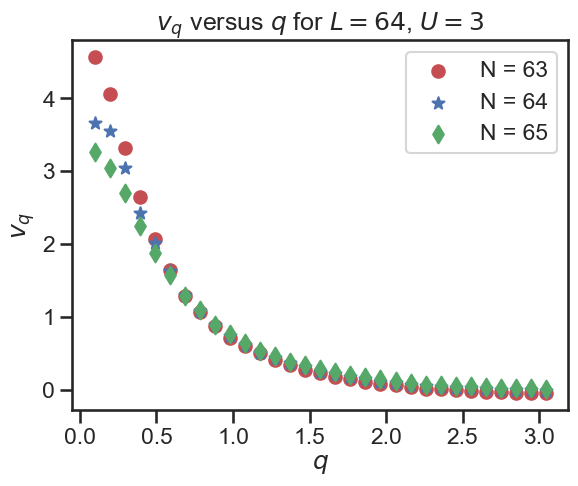

In [11]:
VMC_q_N63_U3, VMC_vq_N63_U3, VMC_vq__q2_N63_U3 = load_vmc_vq("../data/C/1D/L64_N63/jastrow_realspace/VMC_vq_vs_q_U3.0.dat")
VMC_q_N64_U3, VMC_vq_N64_U3, VMC_vq__q2_N64_U3 = load_vmc_vq("../data/C/1D/L64_N64/jastrow_realspace/VMC_vq_vs_q_U3.0.dat")
VMC_q_N65_U3, VMC_vq_N65_U3, VMC_vq__q2_N65_U3 = load_vmc_vq("../data/C/1D/L64_N65/jastrow_realspace/VMC_vq_vs_q_U3.0.dat")

plt.scatter(VMC_q_N63_U3[1:-1], VMC_vq_N63_U3[1:-1], c='r', marker='o', label="N = 63")
plt.scatter(VMC_q_N64_U3[1:-1], VMC_vq_N64_U3[1:-1], c='b', marker='*', label="N = 64")
plt.scatter(VMC_q_N65_U3[1:-1], VMC_vq_N65_U3[1:-1], c='g', marker='d', label="N = 65")
plt.xlabel(r"$q$")
plt.ylabel(r"$v_q$")
plt.title("$v_q$ versus $q$ for $L = 64$, $U=3$")
plt.legend(loc="best")
plt.show()

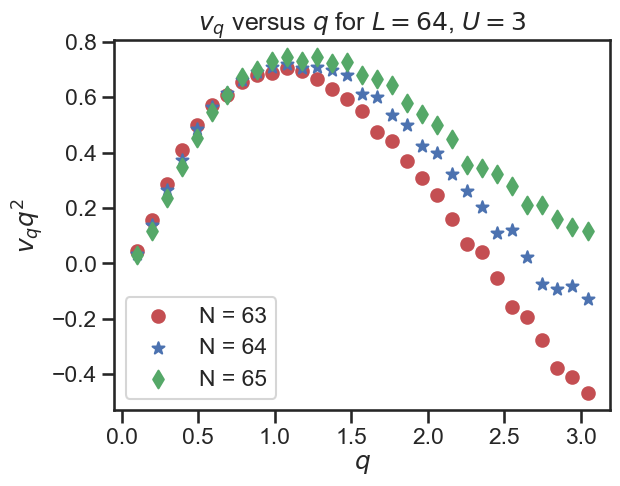

In [12]:
plt.scatter(VMC_q_N63_U3[1:-1], VMC_vq__q2_N63_U3[1:-1], c='r', marker='o', label="N = 63")
plt.scatter(VMC_q_N64_U3[1:-1], VMC_vq__q2_N64_U3[1:-1], c='b', marker='*', label="N = 64")
plt.scatter(VMC_q_N65_U3[1:-1], VMC_vq__q2_N65_U3[1:-1], c='g', marker='d', label="N = 65")
plt.xlabel(r"$q$")
plt.ylabel(r"$v_qq^2$")
plt.title("$v_q$ versus $q$ for $L = 64$, $U=3$")
plt.legend(loc="best")
plt.show()

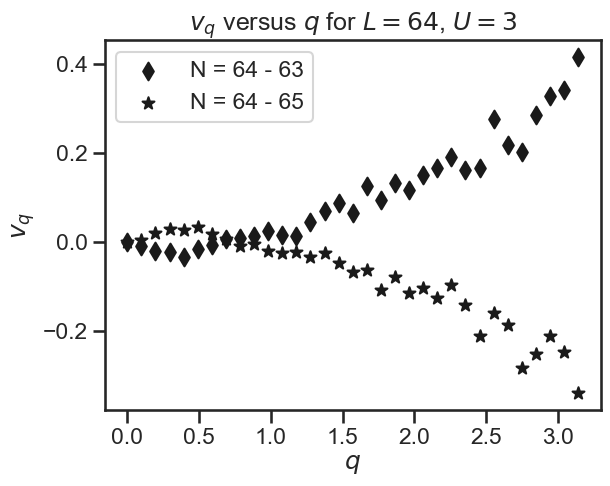

In [13]:
plt.scatter(VMC_q_N64_U3, VMC_vq__q2_N64_U3 - VMC_vq__q2_N63_U3, c='k', marker='d', label="N = 64 - 63")
plt.scatter(VMC_q_N64_U3, VMC_vq__q2_N64_U3 - VMC_vq__q2_N65_U3, c='k', marker='*', label="N = 64 - 65")
plt.xlabel(r"$q$")
plt.ylabel(r"$v_q$")
plt.title("$v_q$ versus $q$ for $L = 64$, $U=3$")
plt.legend(loc="best")
plt.show()

## Real Space Jastrow Potentials

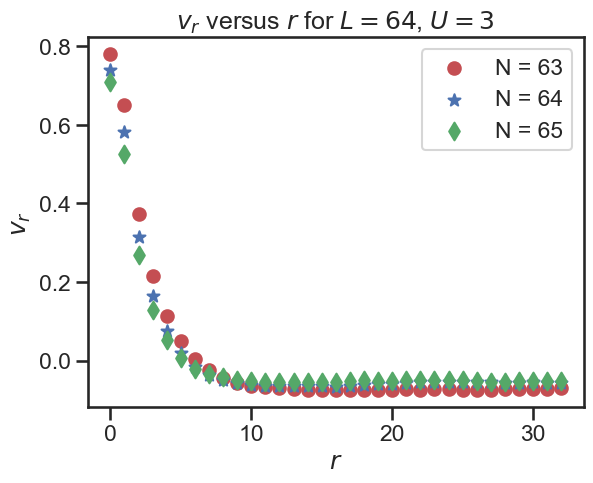

In [39]:
VMC_r_N63_U3, VMC_vr_N63_U3 = load_vmc_vr("../data/C/1D/L64_N63/jastrow_realspace/VMC_vr_vs_r_U3.0.dat")
VMC_r_N64_U3, VMC_vr_N64_U3  = load_vmc_vr("../data/C/1D/L64_N64/jastrow_realspace/VMC_vr_vs_r_U3.0.dat")
VMC_r_N65_U3, VMC_vr_N65_U3 = load_vmc_vr("../data/C/1D/L64_N65/jastrow_realspace/VMC_vr_vs_r_U3.0.dat")

plt.scatter(VMC_r_N63_U3, VMC_vr_N63_U3, c='r', marker='o', label="N = 63")
plt.scatter(VMC_r_N64_U3, VMC_vr_N64_U3, c='b', marker='*', label="N = 64")
plt.scatter(VMC_r_N65_U3, VMC_vr_N65_U3, c='g', marker='d', label="N = 65")
plt.xlabel(r"$r$")
plt.ylabel(r"$v_r$")
plt.title("$v_r$ versus $r$ for $L = 64$, $U=3$")
plt.legend(loc="best")
plt.show()

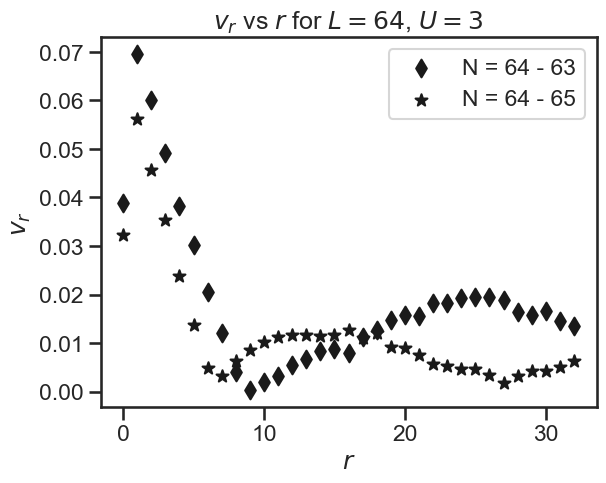

In [15]:
plt.scatter(VMC_r_N64_U3, abs(VMC_vr_N64_U3 - VMC_vr_N63_U3), c='k', marker='d', label="N = 64 - 63")
plt.scatter(VMC_r_N64_U3, abs(VMC_vr_N64_U3 - VMC_vr_N65_U3), c='k', marker='*', label="N = 64 - 65")
plt.xlabel(r"$r$")
plt.ylabel(r"$v_r$")
plt.title("$v_r$ vs $r$ for $L = 64$, $U=3$")
plt.legend(loc="best")
plt.show()

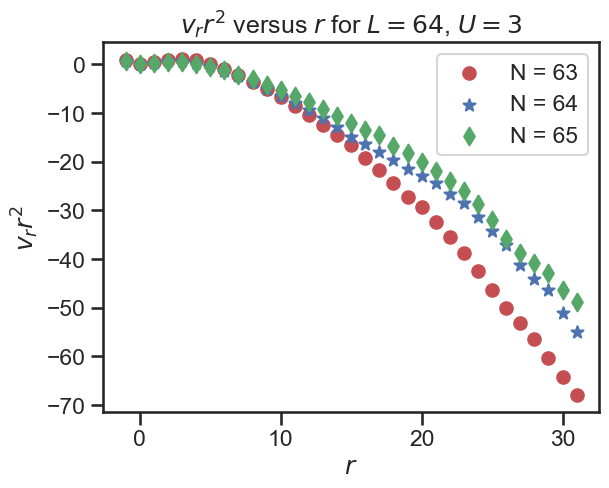

In [45]:
VMC_r_N63_U3, VMC_vr_N63_U3 = load_vmc_vr("../data/C/1D/L64_N63/jastrow_realspace/VMC_vr_vs_r_U3.0.dat")
VMC_r_N64_U3, VMC_vr_N64_U3  = load_vmc_vr("../data/C/1D/L64_N64/jastrow_realspace/VMC_vr_vs_r_U3.0.dat")
VMC_r_N65_U3, VMC_vr_N65_U3 = load_vmc_vr("../data/C/1D/L64_N65/jastrow_realspace/VMC_vr_vs_r_U3.0.dat")

plt.scatter(VMC_r_N63_U3 - 1.0, VMC_vr_N63_U3 * (VMC_r_N63_U3 - 1.0)**2, c='r', marker='o', label="N = 63")
plt.scatter(VMC_r_N64_U3 - 1.0, VMC_vr_N64_U3 * (VMC_r_N64_U3 - 1.0)**2, c='b', marker='*', label="N = 64")
plt.scatter(VMC_r_N65_U3 - 1.0, VMC_vr_N65_U3 * (VMC_r_N65_U3 - 1.0)**2, c='g', marker='d', label="N = 65")
plt.xlabel(r"$r$")
plt.ylabel(r"$v_r r^2$")
plt.title("$v_r r^2$ versus $r$ for $L = 64$, $U=3$")
plt.legend(loc="best")
plt.show()

## $L = 16$ $N=15$ $N=16$ $N=17$ difference without the largest separation Jastrow potential implemented

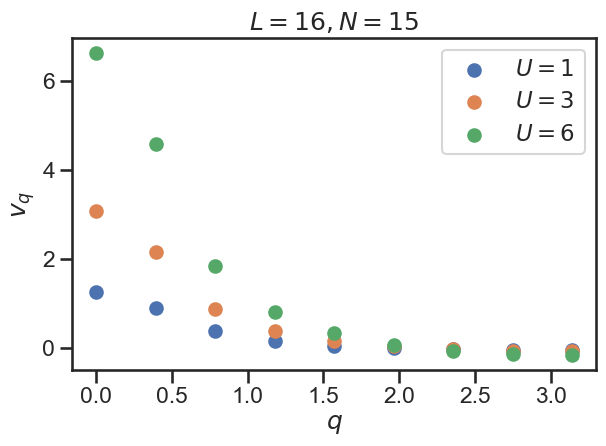

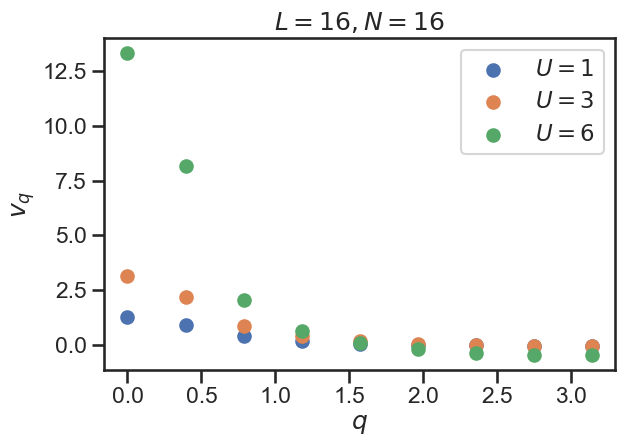

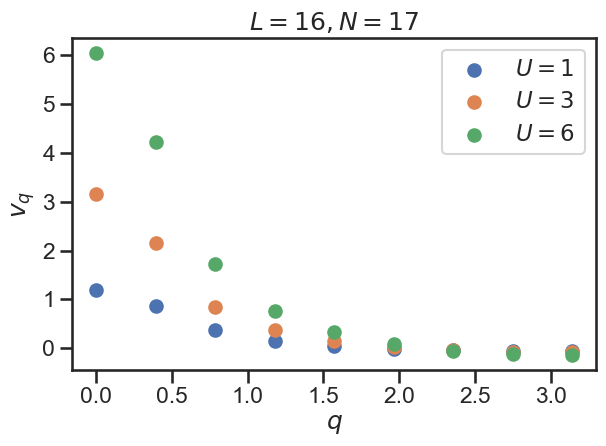

In [22]:
VMC_q_N15_U1, VMC_vq_N15_U1, VMC_vq__q2_N15_U1 = load_vmc_vq("../data/C/1D/L16_N15/jastrow_realspace/VMC_vq_vs_q_U1.0.dat")
VMC_q_N15_U3, VMC_vq_N15_U3, VMC_vq__q2_N15_U3 = load_vmc_vq("../data/C/1D/L16_N15/jastrow_realspace/VMC_vq_vs_q_U3.0.dat")
VMC_q_N15_U6, VMC_vq_N15_U6, VMC_vq__q2_N15_U6 = load_vmc_vq("../data/C/1D/L16_N15/jastrow_realspace/VMC_vq_vs_q_U6.0.dat")

VMC_q_N16_U1, VMC_vq_N16_U1, VMC_vq__q2_N16_U1 = load_vmc_vq("../data/C/1D/L16_N16/jastrow_realspace/VMC_vq_vs_q_U1.0.dat")
VMC_q_N16_U3, VMC_vq_N16_U3, VMC_vq__q2_N16_U3 = load_vmc_vq("../data/C/1D/L16_N16/jastrow_realspace/VMC_vq_vs_q_U3.0.dat")
VMC_q_N16_U6, VMC_vq_N16_U6, VMC_vq__q2_N16_U6 = load_vmc_vq("../data/C/1D/L16_N16/jastrow_realspace/VMC_vq_vs_q_U6.0.dat")

VMC_q_N17_U1, VMC_vq_N17_U1, VMC_vq__q2_N17_U1 = load_vmc_vq("../data/C/1D/L16_N17/jastrow_realspace/VMC_vq_vs_q_U1.0.dat")
VMC_q_N17_U3, VMC_vq_N17_U3, VMC_vq__q2_N17_U3 = load_vmc_vq("../data/C/1D/L16_N17/jastrow_realspace/VMC_vq_vs_q_U3.0.dat")
VMC_q_N17_U6, VMC_vq_N17_U6, VMC_vq__q2_N17_U6 = load_vmc_vq("../data/C/1D/L16_N17/jastrow_realspace/VMC_vq_vs_q_U6.0.dat")

fig, ax = plt.subplots()
ax.scatter(VMC_q_N15_U1, VMC_vq_N15_U1, label="$U=1$")
ax.scatter(VMC_q_N15_U3, VMC_vq_N15_U3, label="$U=3$")
ax.scatter(VMC_q_N15_U3, VMC_vq_N15_U6, label="$U=6$")
ax.set_xlabel(r"$q$")
ax.set_ylabel(r"$v_q$")
ax.legend(loc="best")
ax.set_title(r"$L=16, N=15$")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.scatter(VMC_q_N16_U1, VMC_vq_N16_U1, label="$U=1$")
ax.scatter(VMC_q_N16_U3, VMC_vq_N16_U3, label="$U=3$")
ax.scatter(VMC_q_N16_U3, VMC_vq_N16_U6, label="$U=6$")
ax.set_xlabel(r"$q$")
ax.set_ylabel(r"$v_q$")
ax.legend(loc="best")
ax.set_title(r"$L=16, N=16$")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.scatter(VMC_q_N17_U1, VMC_vq_N17_U1, label="$U=1$")
ax.scatter(VMC_q_N17_U3, VMC_vq_N17_U3, label="$U=3$")
ax.scatter(VMC_q_N17_U3, VMC_vq_N17_U6, label="$U=6$")
ax.set_xlabel(r"$q$")
ax.set_ylabel(r"$v_q$")
ax.legend(loc="best")
ax.set_title(r"$L=16, N=17$")
plt.tight_layout()
plt.show()

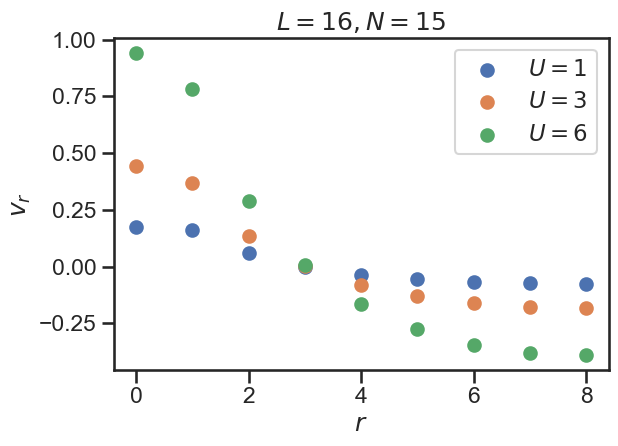

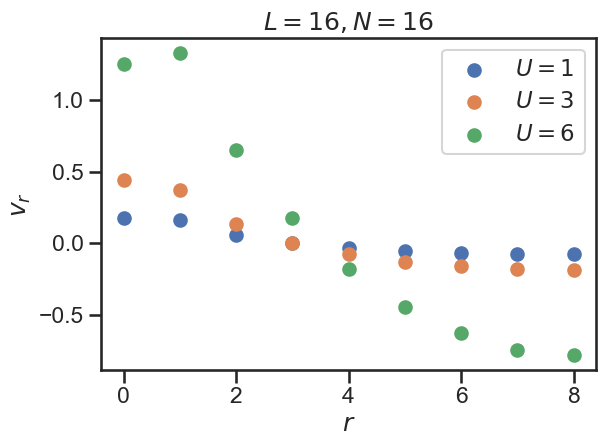

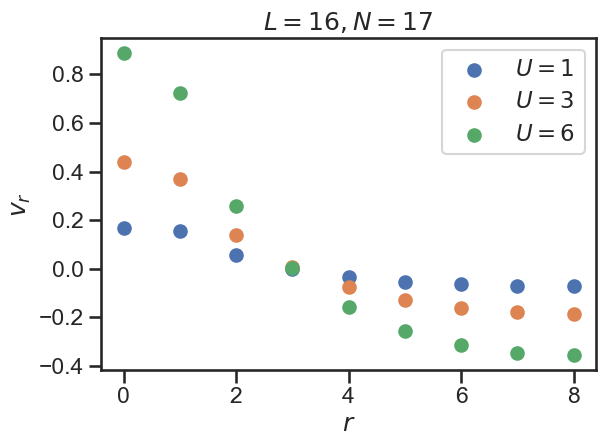

In [24]:
VMC_r_N15_U1, VMC_vr_N15_U1 = load_vmc_vr("../data/C/1D/L16_N15/jastrow_realspace/VMC_vr_vs_r_U1.0.dat")
VMC_r_N15_U3, VMC_vr_N15_U3 = load_vmc_vr("../data/C/1D/L16_N15/jastrow_realspace/VMC_vr_vs_r_U3.0.dat")
VMC_r_N15_U6, VMC_vr_N15_U6 = load_vmc_vr("../data/C/1D/L16_N15/jastrow_realspace/VMC_vr_vs_r_U6.0.dat")

VMC_r_N16_U1, VMC_vr_N16_U1 = load_vmc_vr("../data/C/1D/L16_N16/jastrow_realspace/VMC_vr_vs_r_U1.0.dat")
VMC_r_N16_U3, VMC_vr_N16_U3 = load_vmc_vr("../data/C/1D/L16_N16/jastrow_realspace/VMC_vr_vs_r_U3.0.dat")
VMC_r_N16_U6, VMC_vr_N16_U6 = load_vmc_vr("../data/C/1D/L16_N16/jastrow_realspace/VMC_vr_vs_r_U6.0.dat")

VMC_r_N17_U1, VMC_vr_N17_U1 = load_vmc_vr("../data/C/1D/L16_N17/jastrow_realspace/VMC_vr_vs_r_U1.0.dat")
VMC_r_N17_U3, VMC_vr_N17_U3 = load_vmc_vr("../data/C/1D/L16_N17/jastrow_realspace/VMC_vr_vs_r_U3.0.dat")
VMC_r_N17_U6, VMC_vr_N17_U6 = load_vmc_vr("../data/C/1D/L16_N17/jastrow_realspace/VMC_vr_vs_r_U6.0.dat")

fig, ax = plt.subplots()
ax.scatter(VMC_r_N15_U1, VMC_vr_N15_U1, label="$U=1$")
ax.scatter(VMC_r_N15_U3, VMC_vr_N15_U3, label="$U=3$")
ax.scatter(VMC_r_N15_U3, VMC_vr_N15_U6, label="$U=6$")
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$v_r$")
ax.legend(loc="best")
ax.set_title(r"$L=16, N=15$")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.scatter(VMC_r_N16_U1, VMC_vr_N16_U1, label="$U=1$")
ax.scatter(VMC_r_N16_U3, VMC_vr_N16_U3, label="$U=3$")
ax.scatter(VMC_r_N16_U3, VMC_vr_N16_U6, label="$U=6$")
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$v_r$")
ax.legend(loc="best")
ax.set_title(r"$L=16, N=16$")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.scatter(VMC_r_N17_U1, VMC_vr_N17_U1, label="$U=1$")
ax.scatter(VMC_r_N17_U3, VMC_vr_N17_U3, label="$U=3$")
ax.scatter(VMC_r_N17_U3, VMC_vr_N17_U6, label="$U=6$")
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$v_r$")
ax.legend(loc="best")
ax.set_title(r"$L=16, N=17$")
plt.tight_layout()
plt.show()

In [34]:
def v_diff_calc(J, U):
    u = U / J
    return np.log(np.sqrt(u**2 + 16.0) - u) - np.log(4)

In [35]:
v_diff = v_diff_calc(1.0, 3.3578)
v_diff

-0.7631780270046522

In [36]:
x = -0.3815890134986009 - 0.3815890135060439
x

-0.7631780270046449

# Exact Potential Ground State Energy

In [18]:
def U_calc(J_bar, U):
    J = J_bar

    A = (1/2) * (1 + (U/J + U/J * np.sqrt(U/J + 16) + 16) / ((U/J)**2 + U/J * np.sqrt(U/J + 16) + 
   16))

    return 2 / np.sqrt((U / J)**2 + (U / J) * np.sqrt((U / J) + 16) + 16) * (1/A**2)

In [19]:
x = U_calc(1.0, 3.3578)
x

0.3758681287534906